# Select NGC 5024 (M53) tidal-stream candidates

Selects NGC 5024 (M53) and NGC 5053 tidal-stream candidates from the wide PM-cut Tractor footprint.

1. Load the target + background Tractor files cutouts (rough cut based on flags, RA, DEC, PM box), stack them, and map the raw footprint. Those are made from `get-tractor-footprint.py`.

2. Clean the catalogue on the (g-z) vs (g-r) stellar locus, fitted on cluster members, so only genuine point sources reach the CMD.

3. Load the simulated stream, keep the segment inside the footprint, and fit the great-circle (phi1, phi2) frame.

4. Build a dereddened g-r CMD and keep stars near a MIST isochrone placed at each phi1 bin's distance (via `minimint`).

5. Map what the isochrone cut.

6. Proper motions: the hard PM box around the cluster motion. The PM information is used again in step 7, as the matched-filter PM cut weight.

7. Run a weighted map of kinematic similar to [Grillmair (2019)](https://ui.adsabs.harvard.edu/abs/2019ApJ...884..174G/abstract) to define an on-stream theoretical corridor, plus a background-subtracted along-stream density profile similar to [Price-Whelan & Bonaca 2018](https://arxiv.org/abs/1805.00425). This will enhance signal of stars that has similar characteristics to simulation but not actually accepting it, and in contrast not fully eliminate stars with less-similar characteristics.

8. Cross-match against the DESI MWS RV&[Fe/H] catalogue and weight by radial velocity and metallicity for clusters: NGC 5053's members are separated out of the shared sample by their systemic velocity, NGC 5024's corridor candidates by the simulated stream's v_hel(RA) track.

Each selection step is its own cell: the parameters of the cut, the cut, then the figure showing what it did. Only paths, the cluster identity and its catalog parameters live in the CONFIG cell; every tunable belongs to the step that uses it, so you change a number and re-run the cell right below it.

Edit the paths and cluster name in the CONFIG cell below, then run the cells in order.

## Imports

In [26]:
from __future__ import annotations

from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from astropy.table import Table
from astropy.coordinates import SkyCoord
from astropy import units as u

# Every helper the pipeline uses lives in utils.py next to this notebook: the
# cluster-agnostic building blocks (coordinates, photometry, isochrones, the
# stellar locus, the matched filter, CMD/Hess and PM-GMM diagnostics, sky maps)
# and the NGC 5024 pipeline steps. Edit utils.py and re-run this cell to pick
# the changes up.
%load_ext autoreload
%autoreload 2
from utils import *

%matplotlib inline

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Helper functions

All of them now live in **`utils.py`** beside this notebook, so the notebook
itself is just the pipeline and its parameters. The module has two halves: the cluster-agnostic
building blocks (lifted unchanged from the `streamcutter` package) and the
NGC 5024 pipeline steps, which take the cluster parameters and cut values as
arguments rather than reading globals from here.

`autoreload` is on in the imports cell, so an edit to `utils.py` takes effect
on the next cell you run -- no kernel restart.

## CONFIG

Paths and the two clusters this notebook selects on -- **NGC 5024** and its
companion **NGC 5053** -- with their catalog parameters, plus the footprint
trim. Only what the whole pipeline shares lives here; everything step-specific
(the locus band, the isochrone tolerances, the region widths, the PM box) is
declared at the top of the cell that uses it, so a parameter
and the figure it shapes stay together.

NGC 5053 sits ~1 deg from NGC 5024 at nearly the same distance, metallicity and
proper motion, so the two share the photometric and kinematic selection: the
locus, isochrone and PM cuts are built on NGC 5024 (steps 2, 4, 6) and NGC 5053's
members come along inside the same sample. They part company only in
line-of-sight velocity, so each cluster gets its own RV + [Fe/H] weighting in
step 8 and its own candidate table.

In [27]:
# REPO root: the parent of the folder holding this notebook -- data/ and
# streams_result/ live at the root of the lms-1 repo, one level up from
# stream-select/. Falls back to the cwd when the notebook is run from the root.
REPO = Path.cwd()
if REPO.name in ("stream-select", "scripts"):
    REPO = REPO.parent
NAME = "ngc5024"           # prefix of the *_tgt/_bg Tractor combined FITS
GC1_NAME = "NGC_5024"       # name used to look the cluster up in the catalogs
GC1_LABEL = "NGC 5024"      # short label for plot annotations
RESULT_DIR = Path("/scratch/u/salmanhiro/tractor_wide/ngc5024")
# Simulated streams, one per cluster (same directory / naming convention).
STREAM_FILE_GC1 = Path("/scratch/u/salmanhiro/stream_simulation/fardal/"
                   "McMillan17/simulated_stream_NGC_5024.fits")
STREAM_FILE_GC2 = STREAM_FILE_GC1.parent / "simulated_stream_NGC_5053.fits"
DESI_FILE = REPO / "data" / "RV_T_dr3_filtered.fits"

# Cluster reference catalogs
BAUMGARDT_FILE = REPO / "data" / "mw_gc_parameters_orbital_structural_time.ecsv"
HARRIS_FILE = REPO / "data" / "mwgc.dat"

# Cluster parameters gathered from the catalogs:
#   Baumgardt -> RA, DEC, DIST, VLOS, PMRA, PMDEC, tidal radius
#   Harris    -> [Fe/H]
_gc1 = load_gc_params(GC1_NAME, BAUMGARDT_FILE, HARRIS_FILE)

GC1 = {k: _gc1[k] for k in ("RA", "DEC", "DIST", "VLOS", "PMRA", "PMDEC")}
GC1_RT_PC = _gc1["RT_PC"]     # tidal radius [pc]
GC1_FEH = _gc1["FEH"]         # [Fe/H]
GC1_DIST_KPC = _gc1["DIST"]      # distance [kpc] used for the isochrone distance modulus

# Companion cluster NGC 5053, ~1 deg away. It shares NGC 5024's distance
# (~17.5 vs 18.5 kpc), metallicity ([Fe/H] ~ -2.27 vs -2.1) and proper motion, so
# ONE isochrone + PM selection serves both clusters (steps 4 and 6) -- what
# separates them is the line-of-sight velocity (~ +43 vs -63 km/s), which is why
# both clusters get their own RV + [Fe/H] weighting in step 8.
GC2_NAME = "NGC_5053"
GC2_LABEL = "NGC 5053"
_gc2 = load_gc_params(GC2_NAME, BAUMGARDT_FILE, HARRIS_FILE)
GC2 = {k: _gc2[k] for k in ("RA", "DEC", "DIST", "VLOS", "PMRA", "PMDEC")}
GC2_RT_PC = _gc2["RT_PC"]
GC2_FEH = _gc2["FEH"]
GC2_DIST_KPC = _gc2["DIST"]

# Spatial footprint cut (deg) to trim the wide cutout to the stream region, used
# from step 3 onwards (stream segment, sky maps, PM cut, appendix).
# The Tractor footprint spans RA 174-226, DEC -1 to 35.5 around the cluster.
RA_LIM = (174.0, 226.0)
DEC_LIM = (-1.0, 36.0)

print(f"{GC1_LABEL}: {GC1}")
print(f"  tidal radius: {GC1_RT_PC:.1f} pc  [Fe/H]: {GC1_FEH:.2f}  "
      f"dist: {GC1_DIST_KPC:.1f} kpc")
print(f"{GC2_LABEL}: {GC2}")
print(f"  tidal radius: {GC2_RT_PC:.1f} pc  [Fe/H]: {GC2_FEH:.2f}  "
      f"dist: {GC2_DIST_KPC:.1f} kpc")

NGC 5024: {'RA': 198.230209, 'DEC': 18.168165, 'DIST': 18.5, 'VLOS': -63.37, 'PMRA': -0.131, 'PMDEC': -1.332}
  tidal radius: 183.0 pc  [Fe/H]: -2.10  dist: 18.5 kpc
NGC 5053: {'RA': 199.112885, 'DEC': 17.700251, 'DIST': 17.54, 'VLOS': 42.82, 'PMRA': -0.338, 'PMDEC': -1.214}
  tidal radius: 91.6 pc  [Fe/H]: -2.27  dist: 17.5 kpc


## Selection Pipeline

### 1. Load footprint + sky map

GC tidal radius: 0.567 deg
combined rows: 1005699  (tgt 934026 + bg 71869; dropped 196 duplicate sources)


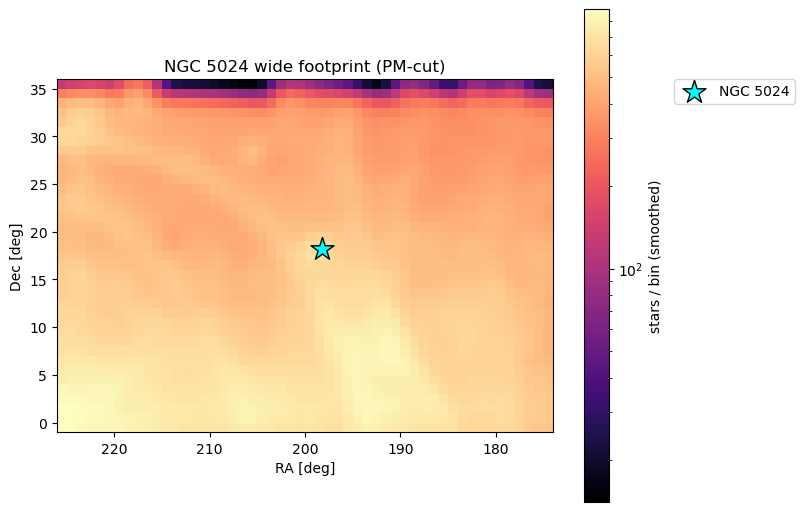

In [28]:
rt_deg = tidal_radius_deg(GC1_RT_PC, GC1["DIST"])
print(f"GC tidal radius: {rt_deg:.3f} deg")

combined = load_combined(RESULT_DIR, NAME)
_ = plot_sky(combined, GC1, GC1_LABEL)

### 2. Stellar-locus (colour-colour) cut

Real point sources follow a tight sequence in `(g-z)` vs `(g-r)`; unresolved
galaxies, blends and sources with one bad band scatter off it. The locus
slope/intercept are **fitted on stars within `LOCUS_APERTURE_DEG` of the cluster
centre** (nearly all genuine members, so the fit also absorbs small zeropoint
offsets) and every star is kept only if its residual `delta_locus` is within
`+/- LOCUS_TOL` mag, inside `LOCUS_GMAG_LIM` and in the colour window
`LOCUS_GR_MIN <= (g-r)_0 <= LOCUS_GR_MAX`. Set `LOCUS_FIT = False` at the top of
the cell below to use the reference locus `(g-z) = 1.7 (g-r) - 0.17` instead.

This runs **before** the isochrone cut: the CMD is only as clean as the
photometry going into it. The figure below shows the colour-colour density
with the fitted locus and its band, plus the residual histogram -- the narrow
spike is the point-source population, the tail is what the cut removes.

[locus] fitted on 1198 stars within 0.5 deg of NGC 5024: g-z = 1.690 (g-r) -0.145  (N_fit=628)


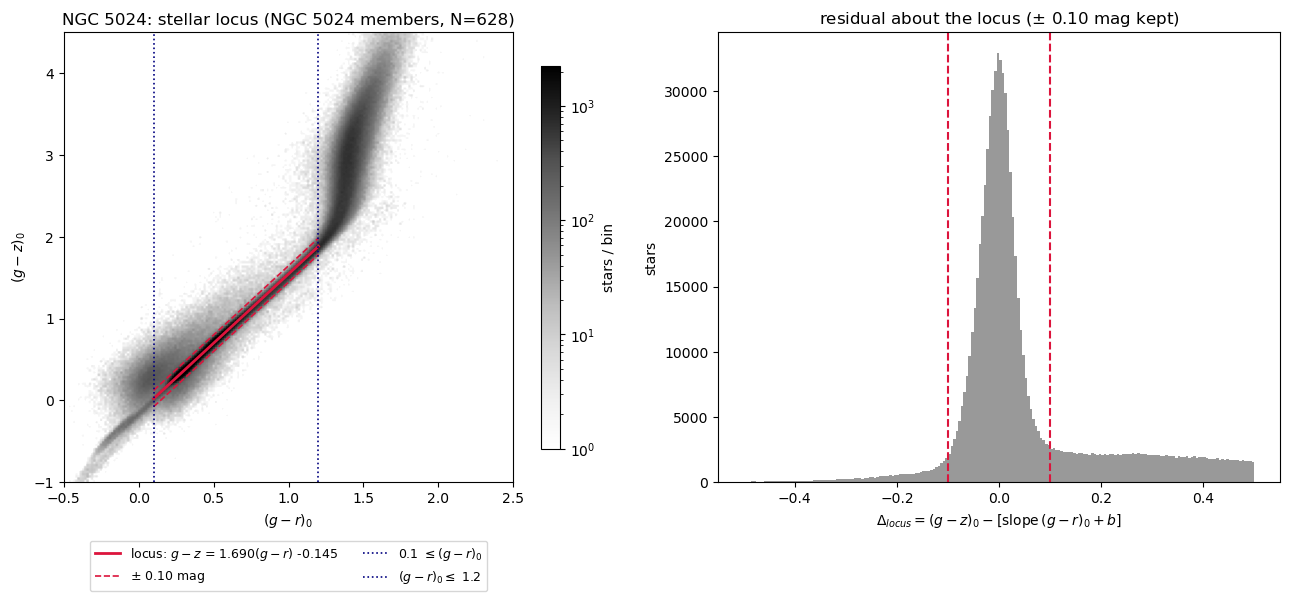

[locus] kept 497612 / 1005699 within +/-0.1 mag, 16.0 <= g < 22.0, 0.1 <= (g-r)_0 <= 1.2


In [29]:
# Parameters of the locus cut, declared here with the figure they shape. The
# slope/intercept are fitted on stars inside LOCUS_APERTURE_DEG of the cluster
# centre (nearly all genuine point sources at one distance, so the fit also
# absorbs small zeropoint offsets); LOCUS_FIT=False uses the reference locus.
LOCUS_FIT = True
LOCUS_APERTURE_DEG = 0.5       # calibration aperture on the cluster
LOCUS_TOL = 0.10               # +/- band about the locus [mag]
LOCUS_GR_MIN = 0.1             # colour window: the linear regime of the locus
LOCUS_GR_MAX = 1.2
LOCUS_GMAG_LIM = (16.0, 22.0)  # saturation .. survey depth

combined = stellar_locus_cut(combined, GC1, GC1_LABEL,
                             fit=LOCUS_FIT, aperture_deg=LOCUS_APERTURE_DEG,
                             tol=LOCUS_TOL, gr_min=LOCUS_GR_MIN,
                             gr_max=LOCUS_GR_MAX,
                             gmag_lim=LOCUS_GMAG_LIM)

### 3. Simulated stream segments + great-circle frame

Both clusters' 5-orbit simulated streams wrap widely across the sky, so keep only
the segments overlapping the (trimmed) footprint. **NGC 5024**'s segment -- a
clean thin great circle -- defines the frame used for the distance binning, the
matched filter and the density profile. **NGC 5053**'s segment is kept alongside
it: it drives no cut -- its members are separated in step 8 by the cluster's
systemic velocity rather than by a track -- but it shows how much of the
predicted companion stream lands in the footprint and supplies the centreline
drawn on the density map in step 11.

The diagnostic below is NGC 5024's track (RA vs Dec, distance, v_hel and PM).

In [30]:
def segment_to_footprint(tab):
    """Keep only the simulated-stream particles inside the trimmed footprint."""
    sra = np.asarray(tab["RA"], float)
    sde = np.asarray(tab["DEC"], float)
    seg = ((sra >= RA_LIM[0]) & (sra <= RA_LIM[1]) &
           (sde >= DEC_LIM[0]) & (sde <= DEC_LIM[1]))
    print(f"simulated stream segment included in footprint: "
          f"{int(seg.sum())} / {seg.size}")
    return tab[seg]


# NGC 5024 drives the pipeline: its stream defines the great-circle frame, the
# distance bins, the matched filter and the density profile.
stream_simulated_n5024 = segment_to_footprint(Table.read(STREAM_FILE_GC1))
# NGC 5053's stream is loaded here too. It drives no cut -- its members are
# separated in step 8 by the cluster's systemic velocity, not by a track -- but
# it shows how much of the predicted companion stream falls in the footprint and
# supplies the centreline drawn on the density map in step 11.
stream_simulated_n5053 = segment_to_footprint(Table.read(STREAM_FILE_GC2))

frame_n5024 = great_circle_frame(stream_simulated_n5024["RA"], stream_simulated_n5024["DEC"],
                           origin_ra=GC1["RA"], origin_dec=GC1["DEC"])

frame_n5053 = great_circle_frame(stream_simulated_n5053["RA"], stream_simulated_n5053["DEC"],
                            origin_ra=GC2["RA"], origin_dec=GC2["DEC"])


simulated stream segment included in footprint: 912 / 998
simulated stream segment included in footprint: 996 / 998


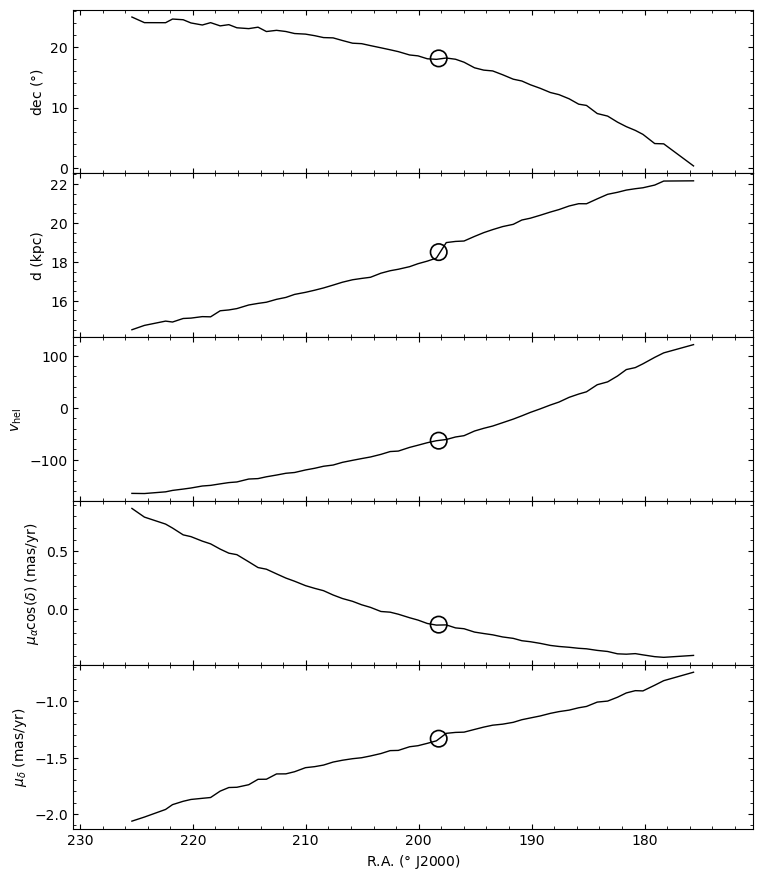

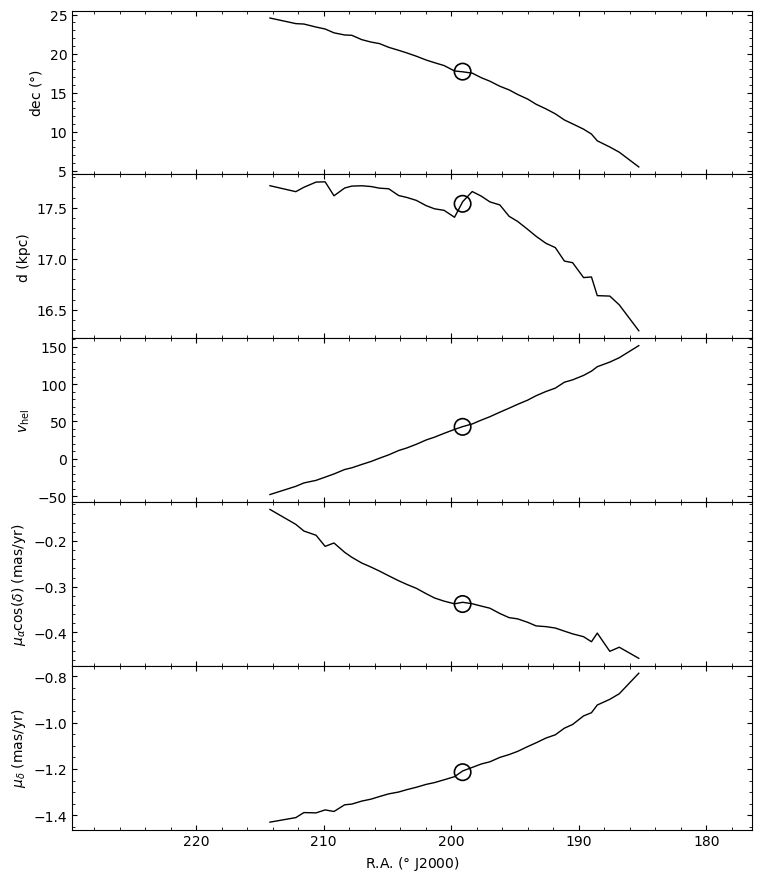

In [31]:
plot_stream(stream_simulated_n5024, GC1, style="track")
plt.show()

plot_stream(stream_simulated_n5053, GC2, style="track")
plt.show()

In [32]:
ex_n5024, ey_n5024, ez_n5024 = frame_n5024
ex_n5053, ey_n5053, ez_n5053 = frame_n5053

# NGC 5024
spmra_n5024 = np.asarray(stream_simulated_n5024["PMRA"], float)
spmdec_n5024 = np.asarray(stream_simulated_n5024["PMDEC"], float)

phi1_n5024, phi2_n5024, mu_phi1_n5024, mu_phi2_n5024 = icrs_to_phi12_and_pm(
    stream_simulated_n5024["RA"], stream_simulated_n5024["DEC"],
    spmra_n5024, spmdec_n5024,
    ex_n5024, ey_n5024, ez_n5024)

stream_simulated_n5024["phi1"] = phi1_n5024
stream_simulated_n5024["phi2"] = phi2_n5024
stream_simulated_n5024["pm_phi1_cosphi2"] = mu_phi1_n5024
stream_simulated_n5024["pm_phi2"] = mu_phi2_n5024

# NGC 5053
spmra_n5053 = np.asarray(stream_simulated_n5053["PMRA"], float)
spmdec_n5053 = np.asarray(stream_simulated_n5053["PMDEC"], float)

phi1_n5053, phi2_n5053, mu_phi1_n5053, mu_phi2_n5053 = icrs_to_phi12_and_pm(
    stream_simulated_n5053["RA"], stream_simulated_n5053["DEC"],
    spmra_n5053, spmdec_n5053,
    ex_n5053, ey_n5053, ez_n5053)

stream_simulated_n5053["phi1"] = phi1_n5053
stream_simulated_n5053["phi2"] = phi2_n5053
stream_simulated_n5053["pm_phi1_cosphi2"] = mu_phi1_n5053
stream_simulated_n5053["pm_phi2"] = mu_phi2_n5053

print(f"NGC 5024: phi1 [{phi1_n5024.min():.2f}, {phi1_n5024.max():.2f}] deg, "
      f"phi2 scatter = {phi2_n5024.std():.3f} deg")
print(f"NGC 5053: phi1 [{phi1_n5053.min():.2f}, {phi1_n5053.max():.2f}] deg, "
      f"phi2 scatter = {phi2_n5053.std():.3f} deg")

NGC 5024: phi1 [-28.47, 26.09] deg, phi2 scatter = 0.954 deg
NGC 5053: phi1 [-23.87, 25.06] deg, phi2 scatter = 0.522 deg


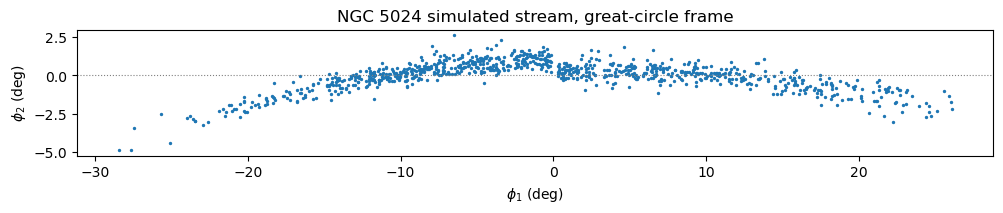

phi1 range: [-28.47, 26.09] deg
phi2 range: [-4.89, 2.62] deg, scatter = 0.954 deg


In [33]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(phi1_n5024, phi2_n5024, s=2, color="tab:blue")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set(xlabel=r"$\phi_1$ (deg)", ylabel=r"$\phi_2$ (deg)",
       title=f"{GC1_LABEL} simulated stream, great-circle frame")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"phi1 range: [{phi1_n5024.min():.2f}, {phi1_n5024.max():.2f}] deg")
print(f"phi2 range: [{phi2_n5024.min():.2f}, {phi2_n5024.max():.2f}] deg, "
      f"scatter = {phi2_n5024.std():.3f} deg")

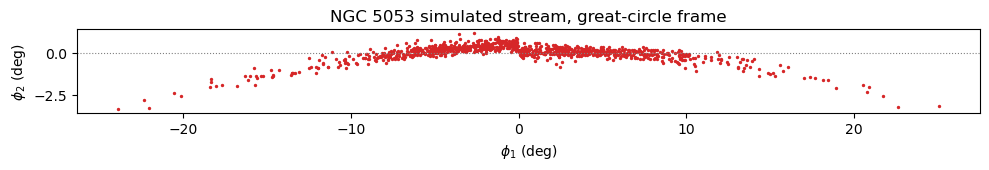

phi1 range: [-23.87, 25.06] deg
phi2 range: [-3.34, 1.17] deg, scatter = 0.522 deg


In [34]:
fig, ax = plt.subplots(figsize=(10, 3.5))
ax.scatter(phi1_n5053, phi2_n5053, s=2, color="tab:red")
ax.axhline(0, color="gray", ls=":", lw=0.8)
ax.set(xlabel=r"$\phi_1$ (deg)", ylabel=r"$\phi_2$ (deg)",
       title=f"{GC2_LABEL} simulated stream, great-circle frame")
ax.set_aspect("equal")
fig.tight_layout()
plt.show()

print(f"phi1 range: [{phi1_n5053.min():.2f}, {phi1_n5053.max():.2f}] deg")
print(f"phi2 range: [{phi2_n5053.min():.2f}, {phi2_n5053.max():.2f}] deg, "
      f"scatter = {phi2_n5053.std():.3f} deg")

#### 3b. Reference overlays for the maps

The catalogues drawn on top of every density map from step 7 onwards, built once
here so all the maps carry the same labelled layers: the simulated stream
centrelines of **NGC 5024**, **NGC 5053** and **NGC 5466**, the published
**LMS-1 STREAMFINDER members** (Malhan+21, Ibata+24), and the centres of
NGC 5024, NGC 5053, NGC 5272 (M3) and NGC 5466.

`overlay_reference` is what the step 7b maps draw. Step 11 rebuilds the same list
with both clusters' spectroscopically confirmed candidates inserted between the
catalogues and the centres -- those only exist after step 9.

In [35]:
# Overlay-only catalogues: NGC 5466's simulated stream and the published
# STREAMFINDER members. Neither drives a cut; both are drawn for comparison.
STREAM_FILE_GC3 = STREAM_FILE_GC1.parent / "simulated_stream_NGC_5466.fits"
STREAMFINDER_FILE = REPO / "data" / "cleaned_streamfinder_ibata24.csv"
# NGC 5024 / 5053 centres come from the catalogs (GC1 / GC2); NGC 5272 (M3) and
# NGC 5466 are the Harris (2010) centres, for spatial reference only.
NGC5272_CENTRE = (205.548424, 28.377275)
NGC5466_CENTRE = (211.363583, 28.534444)

stream_simulated_n5466 = segment_to_footprint(Table.read(STREAM_FILE_GC3))
print(f"simulated particles in footprint: {len(stream_simulated_n5024)} "
      f"({GC1_LABEL}) + {len(stream_simulated_n5053)} ({GC2_LABEL})"
      f" + {len(stream_simulated_n5466)} (NGC 5466)")

# published LMS-1 members inside the footprint (uppercase RA/DEC columns)
lms1_members = load_lms1_template(STREAMFINDER_FILE, RA_LIM, DEC_LIM)

gc1_centre = Table({"RA": [GC1["RA"]], "DEC": [GC1["DEC"]]})
gc2_centre = Table({"RA": [GC2["RA"]], "DEC": [GC2["DEC"]]})
ngc5272_centre = Table({"RA": [NGC5272_CENTRE[0]], "DEC": [NGC5272_CENTRE[1]]})
ngc5466_centre = Table({"RA": [NGC5466_CENTRE[0]], "DEC": [NGC5466_CENTRE[1]]})

# stream centrelines + published members, in contrasting colours against magma.
# style="line" bins the particles into a smooth track instead of scattering them.
overlay_streams = [
    dict(tab=stream_simulated_n5024, cols=("RA", "DEC"), style="line",
         label=f"{GC1_LABEL} sim stream", color="cyan", lw=2.2, alpha=0.9),
    dict(tab=stream_simulated_n5053, cols=("RA", "DEC"), style="line",
         label=f"{GC2_LABEL} sim stream", color="white", lw=2.2, alpha=0.9),
    dict(tab=stream_simulated_n5466, cols=("RA", "DEC"), style="line",
         label="NGC 5466 sim stream", color="orange", lw=2.2, alpha=0.9),
    dict(tab=lms1_members, cols=("RA", "DEC"),
         label="LMS-1 (Malhan+21, Ibata+24)", color="deepskyblue",
         marker="o", s=22, alpha=0.85, edgecolor="k", lw=0.3),
]
# Spectroscopically confirmed candidates. They are produced by steps 8-9, so the
# step 7 maps do not carry them; step 11 inserts them with candidate_layers.
def candidate_layers(tab_gc1, tab_gc2):
    """The two spec.-candidate overlay layers, styled the same everywhere."""
    return [
        dict(tab=tab_gc1, cols=("ra", "dec"),
             label=f"{GC1_LABEL} spec. candidates", color="lime", marker="*",
             s=110, edgecolor="k", lw=0.7),
        dict(tab=tab_gc2, cols=("ra", "dec"),
             label=f"{GC2_LABEL} spec. candidates", color="magenta", marker="*",
             s=110, edgecolor="k", lw=0.7),
    ]


# cluster centres, listed last so they are drawn on top
overlay_centres = [
    dict(tab=gc1_centre, cols=("RA", "DEC"), label=f"{GC1_LABEL} centre",
         color="lime", marker="*", s=260, edgecolor="white", lw=1.3),
    dict(tab=gc2_centre, cols=("RA", "DEC"), label=f"{GC2_LABEL} centre",
         color="magenta", marker="*", s=260, edgecolor="white", lw=1.3),
    dict(tab=ngc5272_centre, cols=("RA", "DEC"), label="NGC 5272 (M3)",
         color="yellow", marker="*", s=200, edgecolor="k", lw=1.0),
    dict(tab=ngc5466_centre, cols=("RA", "DEC"), label="NGC 5466",
         color="white", marker="*", s=200, edgecolor="k", lw=1.0),
]
# What the step 7 maps draw: stream centrelines, published members, cluster
# centres. Step 11 rebuilds the same list with both clusters' candidates inserted
# before the centres.
overlay_reference = overlay_streams + overlay_centres

simulated stream segment included in footprint: 679 / 998
simulated particles in footprint: 912 (NGC 5024) + 996 (NGC 5053) + 679 (NGC 5466)
LMS-1 template: 77 members in footprint (pmRA med -0.12, pmDE med -1.33)


### 4. Isochrone (CMD) selection

Each star is judged against the MIST isochrone placed at the distance of its own
phi1 bin (the simulated stream runs 15.0-21.6 kpc across the footprint), with a
magnitude-dependent colour tolerance. This cell only *tags* the stars
(`keep_iso`). The Hess CMD below shows **every** star in the footprint -- nothing
is filtered out of the map -- with the selection drawn over it: the isochrone
ridge (bold) and its dashed colour-tolerance edges at the median bin distance,
plus thin lines for the other distance bins. Stars kept are the union of the
per-bin bands, so more stars are kept than the single drawn band encloses.

The cut's own parameters -- the g-band window and the colour tolerance -- are
declared in the next cell, right above the figure they shape, and passed in
explicitly. The companion cluster **NGC 5053** is drawn as a second, separate
isochrone (blue, at its own distance and [Fe/H]) for comparison only; nothing
is selected on it.

In [36]:
# Parameters of the isochrone cut, declared here so they sit with the figure
# they shape -- change them and re-run this cell and the next.

# Isochrone / CMD parameters. Age is not in either catalog -> set by hand.
# NGC 5024 (M53) is an old, very metal-poor halo cluster (~12.7 Gyr, [Fe/H] ~ -2.1),
# at ~18.5 kpc so its main-sequence turnoff sits near r ~ 20.
GC1_AGE_GYR = 12.67
ISO_FILTERS = ("DECam_g", "DECam_r")
CMD_NBINS = 5             # phi1 distance bins the isochrone is stepped through

# g-band window
MAG_BRIGHT_LIM_G = 16.5   # saturation / non-linearity
MAG_FAINT_LIM_G  = 20.5   # adopted completeness limit

# Colour tolerance about the isochrone ridge: ramps linearly from ISO_BASE_TOL
# at g = 18 to ISO_FAINT_TOL at g = 21 (clamped outside that range), so the band
# widens where the Tractor photometry gets noisy. These are the dashed edges
# drawn on the CMD below.
ISO_TOL_MINUS  = 0.1
ISO_TOL_PLUS = 0.3

# Photometric limits shared by every CMD figure and by the on-stream /
# background regions of step 4b: stars outside them are tagged "none" (they
# enter neither sample) and the CMD axes use the same ranges. Use (None, x) or
# (x, None) to leave one side open, or None for no limit at all.
CMD_GMAG_LIM = (16.0, 22.0)      # limiting magnitude of the diagnostics
CMD_GRCOLOR_LIM = (0.0, 1.0)

# NGC 5053's age is not in either catalog -> set by hand, as for NGC 5024. It is
# used only to DRAW the companion isochrone below (blue, at its own distance and
# [Fe/H]); the cut itself is the NGC 5024 one, which serves both clusters.
GC2_AGE_GYR = 12.5

[dist bins] 5 phi1 bins over [-21.2, 26.0] deg, sim distance 15.3-21.1 kpc
g magnitude limits [16.5, 20.5]: rejected 310606 of 497612 stars
  d =  15.3 kpc  (m-M = 15.92):  3.0% of isochrone visible, probes to M_g =  4.58
  d =  16.5 kpc  (m-M = 16.09):  2.6% of isochrone visible, probes to M_g =  4.41
  d =  17.9 kpc  (m-M = 16.27):  2.2% of isochrone visible, probes to M_g =  4.23
  d =  20.0 kpc  (m-M = 16.51):  1.6% of isochrone visible, probes to M_g =  3.99
  d =  21.1 kpc  (m-M = 16.62):  1.4% of isochrone visible, probes to M_g =  3.88
selected 132237 / 179099 stars near isochrone (distance-resolved)


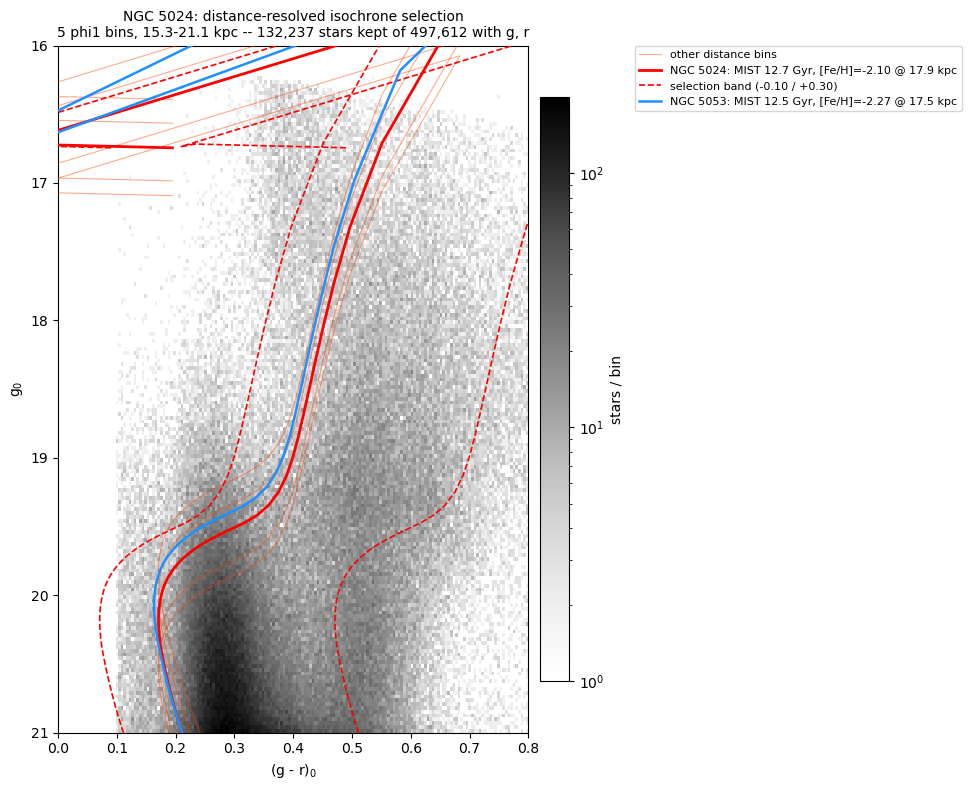

In [37]:
from isochrone import isochrone_select, cmd_hess_regions

combined = assign_dist_bins(combined, stream_simulated_n5024, frame_n5024,
                            nbins=CMD_NBINS, fallback_kpc=GC1_DIST_KPC)

_, _, iso2_g_abs, iso2_r_abs = mist_isochrone(GC2_AGE_GYR, GC2_FEH, ISO_FILTERS)

combined, iso_g_abs, iso_r_abs, fig = isochrone_select(
    combined, MAG_BRIGHT_LIM_G, MAG_FAINT_LIM_G, ISO_TOL_MINUS, ISO_TOL_PLUS,
    GC1_LABEL, GC1_AGE_GYR, GC1_FEH, filters=ISO_FILTERS,
    overlays=[dict(g_abs=iso2_g_abs, r_abs=iso2_r_abs, dist_kpc=GC2_DIST_KPC,
                   color="dodgerblue", ls="-",
                   label=f"{GC2_LABEL}: MIST {GC2_AGE_GYR:.1f} Gyr, "
                         f"[Fe/H]={GC2_FEH:.2f}")])

#### 4b. Per-bin Hess CMD diagnostic

The same cut broken out per phi1 distance bin, against the on-stream /
background regions of the density profile: target CMD + isochrone band, target
Hess, background Hess, and the background-subtracted Hess difference.
Every target / background star is plotted, inside the colour band or not --
the band is drawn over the full CMD (in the CMD panel, stars inside the band
are black and stars outside it grey).

The region geometry is declared at the top of the cell below:
`REGION_ON_RT` / `REGION_BG_OFFSET_RT` / `REGION_BG_WIDTH_RT` / `GC_MASK_RT`
give the cross-track bands in tidal radii (converted to degrees there and
printed by `assign_stream_regions`). The photometric limits `CMD_GMAG_LIM` /
`CMD_GRCOLOR_LIM` come from the isochrone parameters in step 4 -- stars outside
them are tagged `none`, so they are excluded from the target and background
counts and from these Hess panels.

[regions] on_width=5.669 bg=[5.669,11.337] deg gc_mask=1.134 deg mag=[16.5, 20.5] colour=[0.0, 1.0] -> target=59849  background=51723
[hess] target 59849 (45936 in band), background 51723 (39412 in band)
  bin 0: target max 1.35, background max 1.24, diff [-0.14, 0.31] stars/deg2
  bin 1: target max 1.03, background max 0.96, diff [-0.21, 0.24] stars/deg2
  bin 2: target max 0.78, background max 0.80, diff [-0.16, 0.20] stars/deg2
  bin 3: target max 0.71, background max 0.60, diff [-0.26, 0.19] stars/deg2
  bin 4: target max 0.60, background max 0.54, diff [-0.11, 0.28] stars/deg2


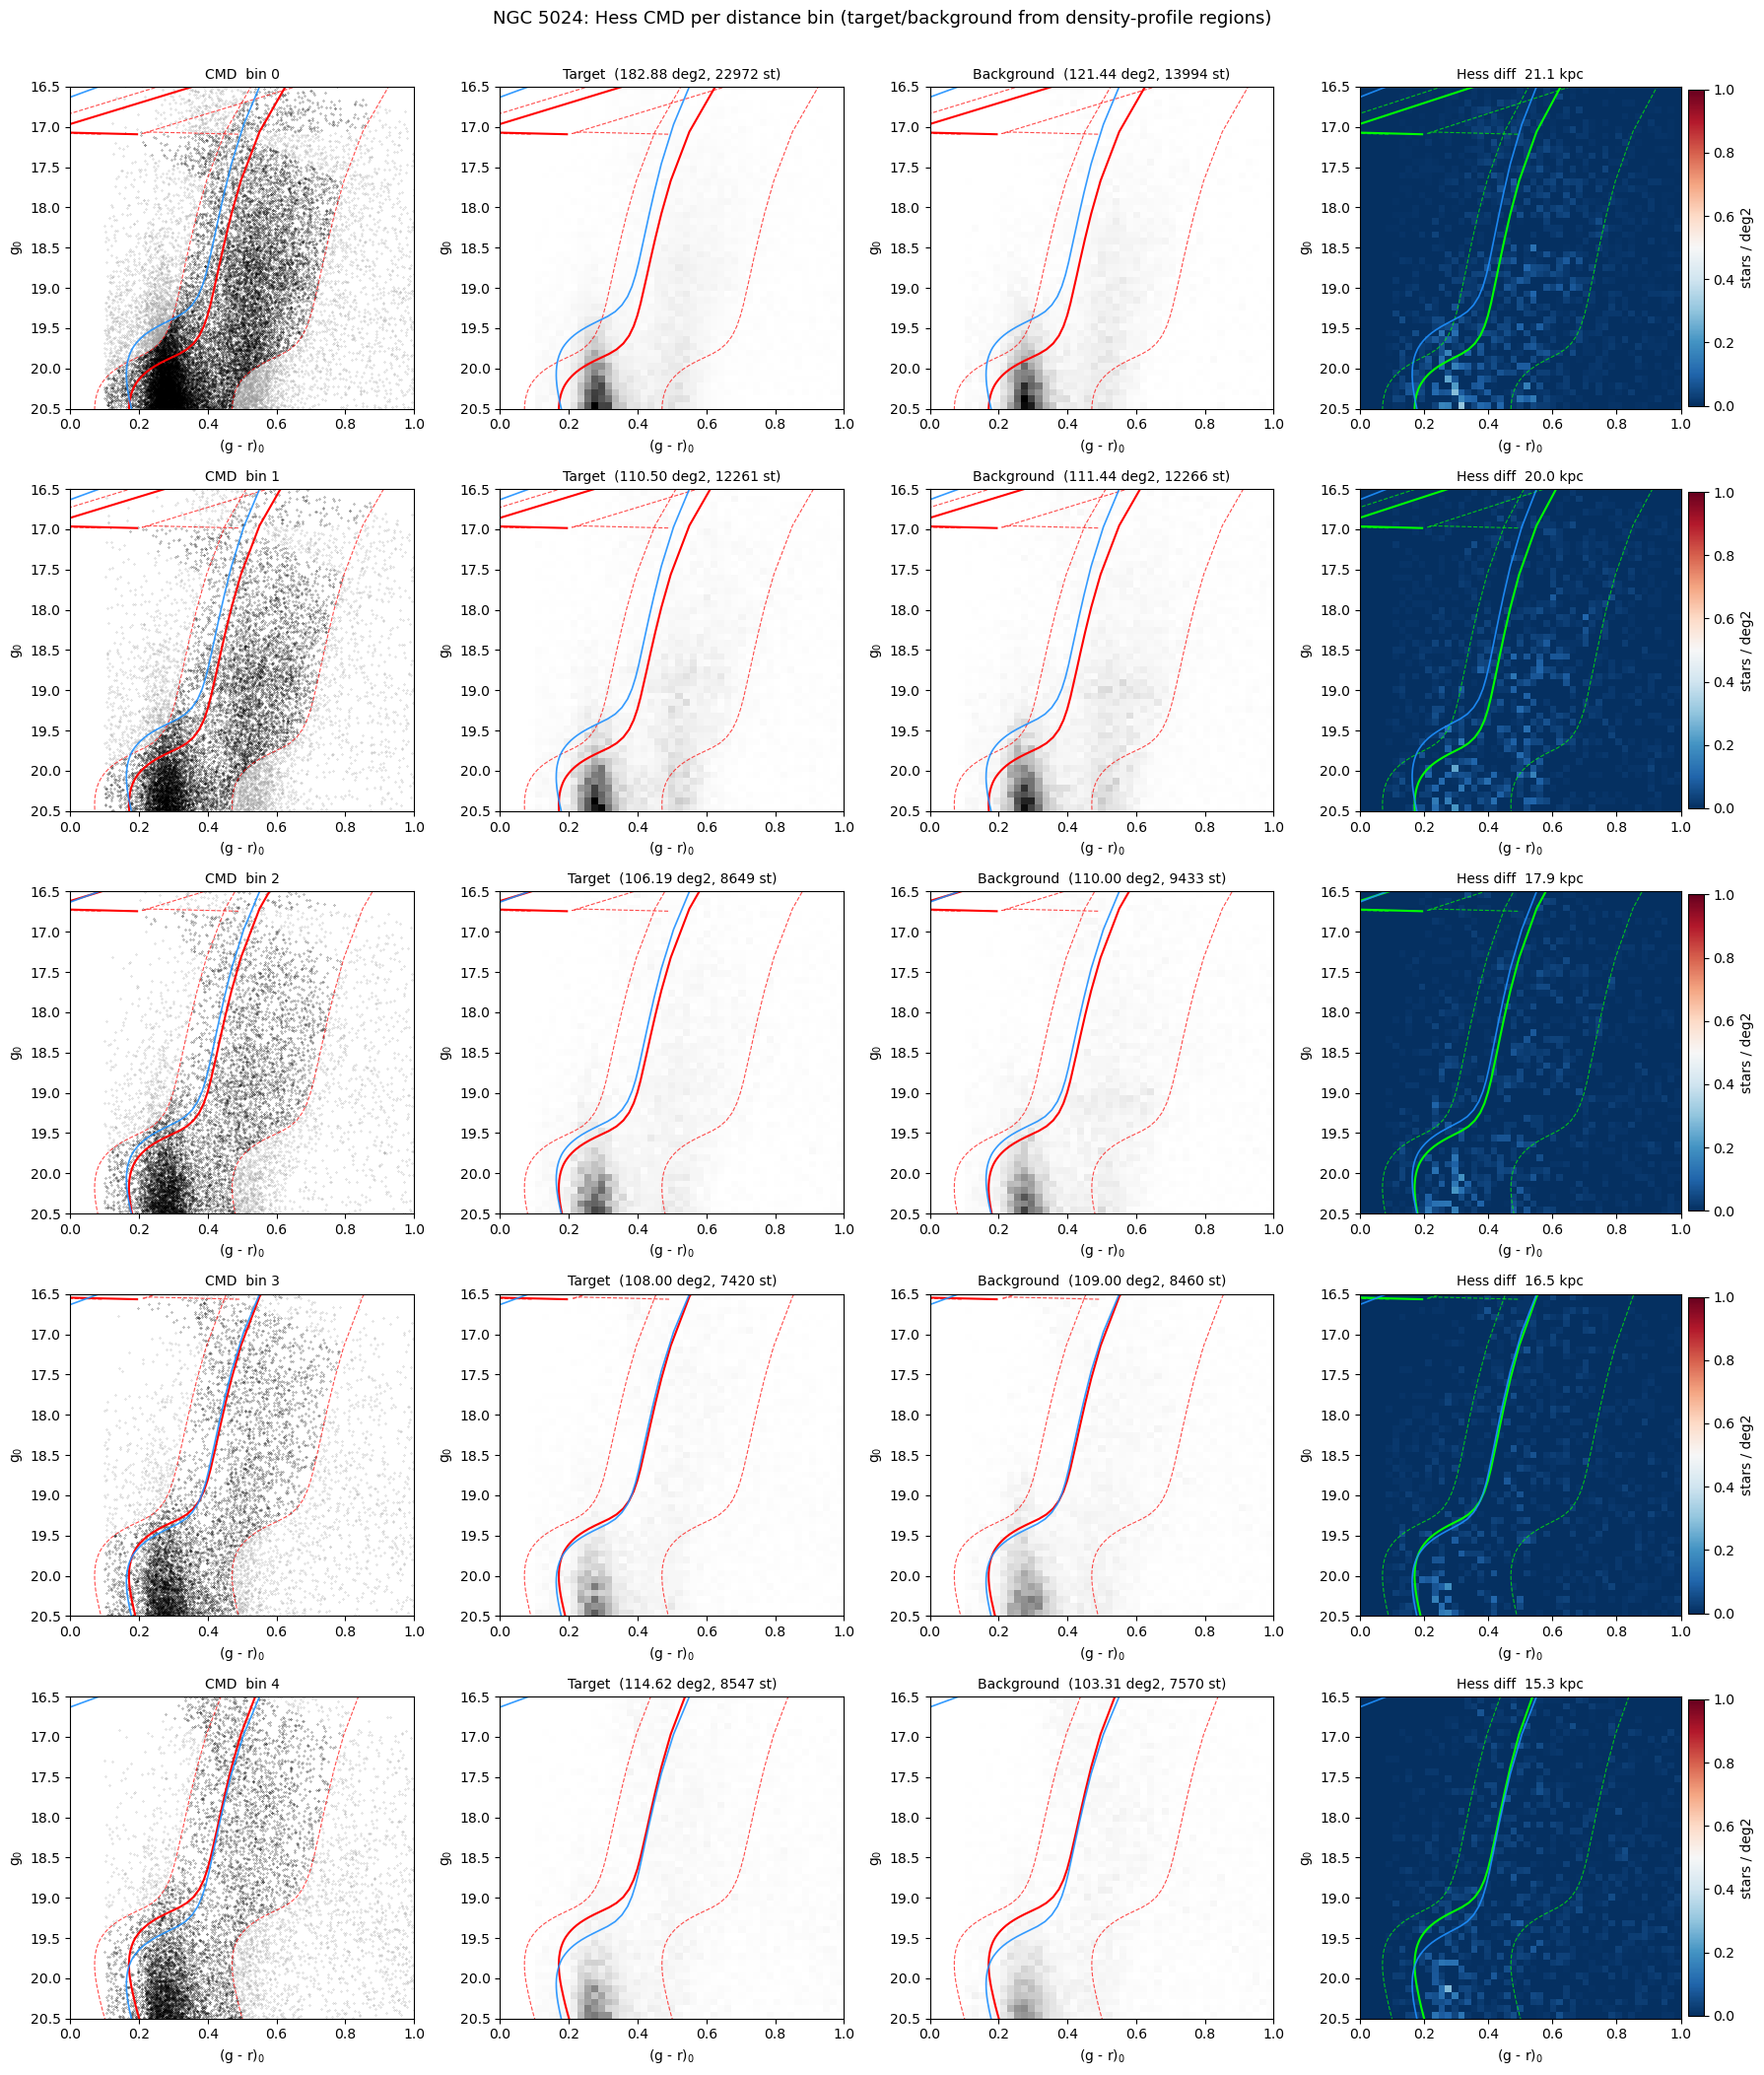

In [38]:
REGION_ON_RT = 10.0
REGION_BG_OFFSET_RT = 10.0
REGION_BG_WIDTH_RT = 10.0
GC_MASK_RT = 2.0
CMD_HESS_NBINS = (49, 49)

on_w = REGION_ON_RT * rt_deg
bg_off = REGION_BG_OFFSET_RT * rt_deg
bg_w = REGION_BG_WIDTH_RT * rt_deg
gc_mask = GC_MASK_RT * rt_deg

combined = assign_stream_regions(combined, stream_simulated_n5024, frame_n5024,
                                 GC1, on_w, bg_off, bg_w, gc_mask,
                                 mag_col="gmag",
                                 mag_lim=(MAG_BRIGHT_LIM_G, MAG_FAINT_LIM_G),
                                 color_col="grcolor", color_lim=CMD_GRCOLOR_LIM)

_ = cmd_hess_regions(combined, iso_g_abs, iso_r_abs, GC1_LABEL,
                     ISO_TOL_MINUS, ISO_TOL_PLUS,
                     MAG_BRIGHT_LIM_G, MAG_FAINT_LIM_G,
                     gr_lim=CMD_GRCOLOR_LIM, hess_bins=CMD_HESS_NBINS,
                     diff_vmax=1,
                     overlays=[dict(g_abs=iso2_g_abs, r_abs=iso2_r_abs,
                                    dist_kpc=GC2_DIST_KPC, color="dodgerblue")])

### 5. Sky after the isochrone cut

What the CMD cut leaves on the sky, in the same RA/Dec frame as the raw
footprint map of step 1.

The colour scale defaults to the 50th-99.5th percentile of the occupied bins.
Every `plot_sky_stage` call forwards extra keywords to `plot_sky_sample`, so pass
`vmin=` / `vmax=` (stars per smoothed bin) to set either end by hand when the
cluster core or the low-Dec field saturates the map, `vmin_pct=` / `vmax_pct=`
to move the percentiles, `log=False` for a linear stretch, or `bin_deg=` /
`smooth_deg=` / `cmap=`. Each call prints the actual bin range and the limits it
used, which is the easiest way to choose numbers.


[sky map] raw bins 0-249 stars (0.5 deg pixels); displayed 0-249; colour scale 0-30  [set by hand]


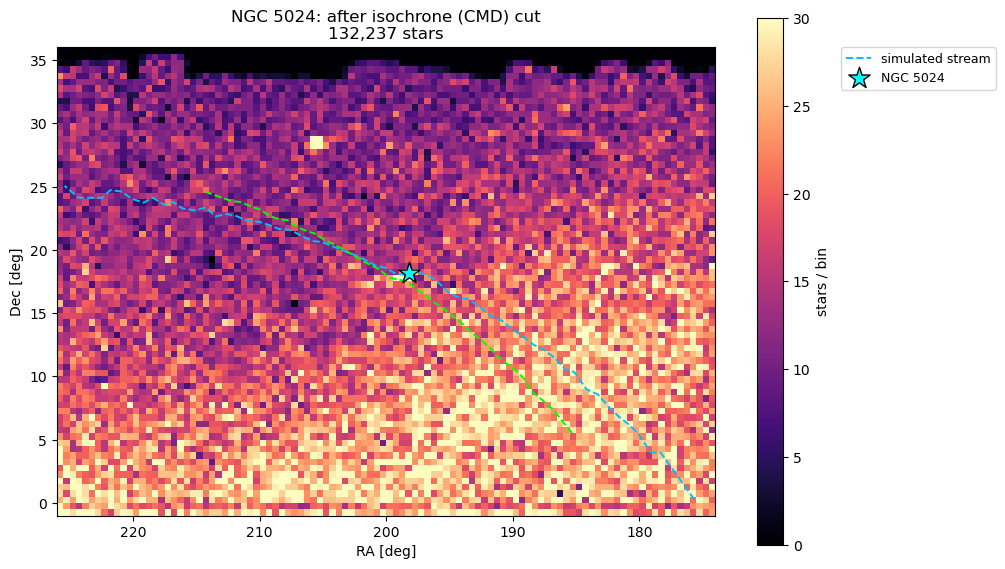

In [39]:
combined_cmd = combined[np.asarray(combined["keep_iso"], bool)]
_ = plot_sky_stage(combined_cmd, f"{GC1_LABEL}: after isochrone (CMD) cut",
                   GC1, GC1_LABEL, RA_LIM, DEC_LIM,
                   stream=stream_simulated_n5024,
                   normalize_bg=False, bin_deg=0.5, vmax=30,
                   overlays=[dict(tab=stream_simulated_n5053, color="lime")])

### 6. Proper-motion selection

Proper motion enters the pipeline twice, and neither time as a mixture model:

1. **here**, as the hard `PM_BOX` (+/- 1 mas/yr around the cluster motion) plus
   the RA/Dec footprint trim -- a preliminary cut that throws away the bulk of
   the field before any weighting;
2. **in step 7**, as the *weight* itself: `matched_filter_map` scores every
   surviving star by how well its PM agrees with the simulated stream's PM(RA)
   track, given its own PM errors (Grillmair 2019). That weighted map, and the
   corridor drawn from it, is what actually selects the candidates.

The PM GMM that used to sit here (a mixture in (pmra, pmdec) with the stream's
own PM distribution frozen in as a component, giving each star a `P_stream`) has
been removed. It was never applied in the original pipeline -- `PM_GMM_PMIN` was
`None`, so it only ever produced a diagnostic figure -- and it is fragile in this
field: LMS-1 debris shares NGC 5024's proper motion, so the stream component
either collapses to `min_weight` or simply re-describes the field. The matched
filter uses the same PM information continuously, with the per-star errors, and
without a fit that can flip. `pm_gmm_step` / `pm_gmm_select` are still in
`utils.py` if you want the diagnostic back.

Note (see the LMS-1 caveat at the end of this notebook): in this field LMS-1's
proper motion is indistinguishable from NGC 5024's, so the box does not separate
cluster debris from LMS-1 debris -- and nothing else in the PM plane would.

In [40]:
# Proper-motion box selecting the cluster motion (mas/yr); manual selection cut
# (NGC 5024 +/- 1 mas/yr around PMRA=-0.13, PMDEC=-1.33). This is the whole PM
# selection: from here on the proper motions are used as a matched-filter weight
# (step 7), not as another cut.
PM_BOX = dict(pmra_min=-1.13, pmra_max=0.87, pmdec_min=-2.33, pmdec_max=-0.33)

combined_iso = apply_pm_cut(combined_cmd, PM_BOX, RA_LIM, DEC_LIM)

PM box + footprint: kept 31835 / 132237


#### 6b. Sky after the PM selection

The photometric + kinematic sample that goes into the matched filter below.

[sky map] background fitted on 89% of pixels (> 2.0 deg off track), smoothed 5.0 deg
[sky map] raw bins 0-213 stars (1 deg pixels); displayed 0-13.3; colour scale 0.124-3  [set by hand]


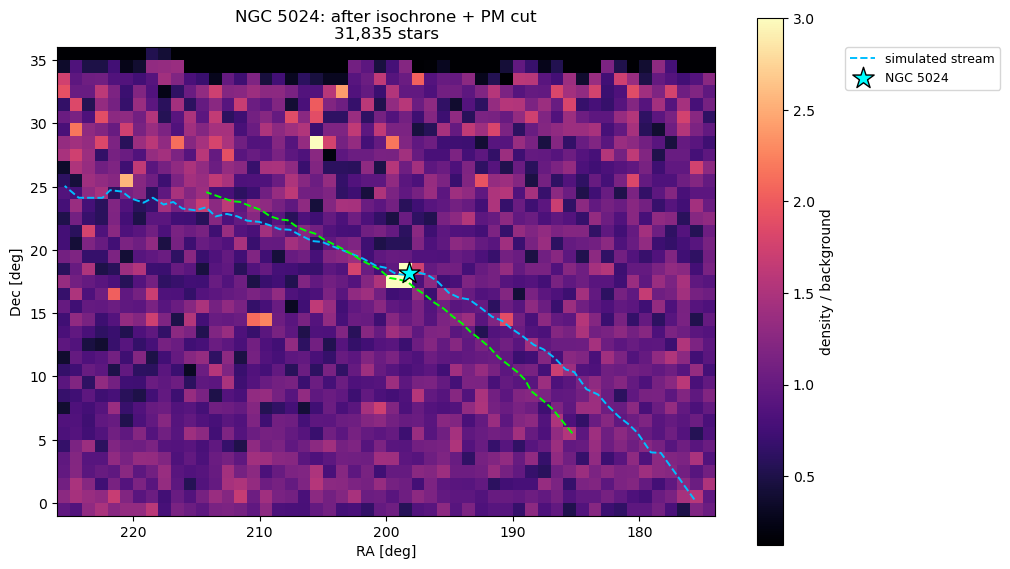

In [41]:
_ = plot_sky_stage(combined_iso, f"{GC1_LABEL}: after isochrone + PM cut",
                   GC1, GC1_LABEL, RA_LIM, DEC_LIM,
                   stream=stream_simulated_n5024, bin_deg=1, vmax=3,
                   overlays=[dict(tab=stream_simulated_n5053, color="lime")])

### 7. Kinematic matched-filter corridor

The PM selection proper: every star surviving the box is weighted by how well
its proper motion matches the simulated stream's PM(RA) track given its own PM
errors, and the weighted map is smoothed into a density. Stars inside the
`band_width` corridor around the stream track become `candidates` -- the sample
the DESI cross-match and the RV / [Fe/H] weighting run on in step 8. This is the
selection, not a preview of one.

[matched filter] N_stars=31835  N_eff=9848  (N_eff/N=0.309)
[matched filter] stars inside band = 2996/31835  (sum w inside = 753 of 5745)


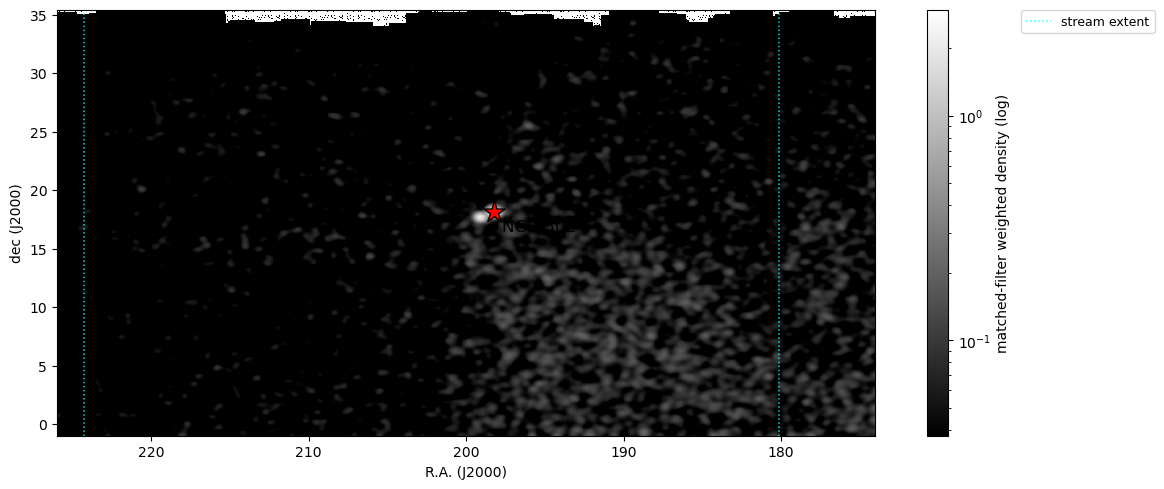

matched-filter corridor (|dphi2| < 1.70 deg): 2996 / 31835 stars


In [42]:
# Corridor half-width around the stream track, in tidal radii.
band_width = 3 * rt_deg

# matched_filter_map draws its figure inline; keep the returned corridor mask.
fig, in_band = matched_filter_map(
    combined_iso, stream_simulated_n5024, GC1, gc_label=GC1_LABEL,
    pmra_ivar="pmra_ivar", pmdec_ivar="pmdec_ivar",
    cmap="gray", vmin_pct=70, show_band=False, show_track=False,
    band_width_deg=band_width, return_mask=True, pix=0.1, smooth_deg=0.2)
candidates = combined_iso[in_band]
print(f"matched-filter corridor (|dphi2| < {band_width:.2f} deg): "
      f"{len(candidates)} / {len(combined_iso)} stars")

#### 7b. Matched-filter weighted background-subtracted density profile

The CMD (isochrone) sample is weighted by the PM
matched-filter weight -- the same weighting as the step 7 map -- NOT the RV/[Fe/H]
selection. A great-circle stream frame (phi1, phi2) is fit to the simulated
stream and the cluster is masked so it does not spike the on-stream bin.

[density profile] masked 438 stars within 1.13 deg of NGC 5024
[density profile] frame phi2 track curvature: 4.034 deg peak-to-peak (smoothed; 5.926 raw) over 53.0 deg of phi1 -- the simulation is nearly a great circle in this frame
[density profile] weighted on-stream=2436  background=1709  (bg scale=1.00)


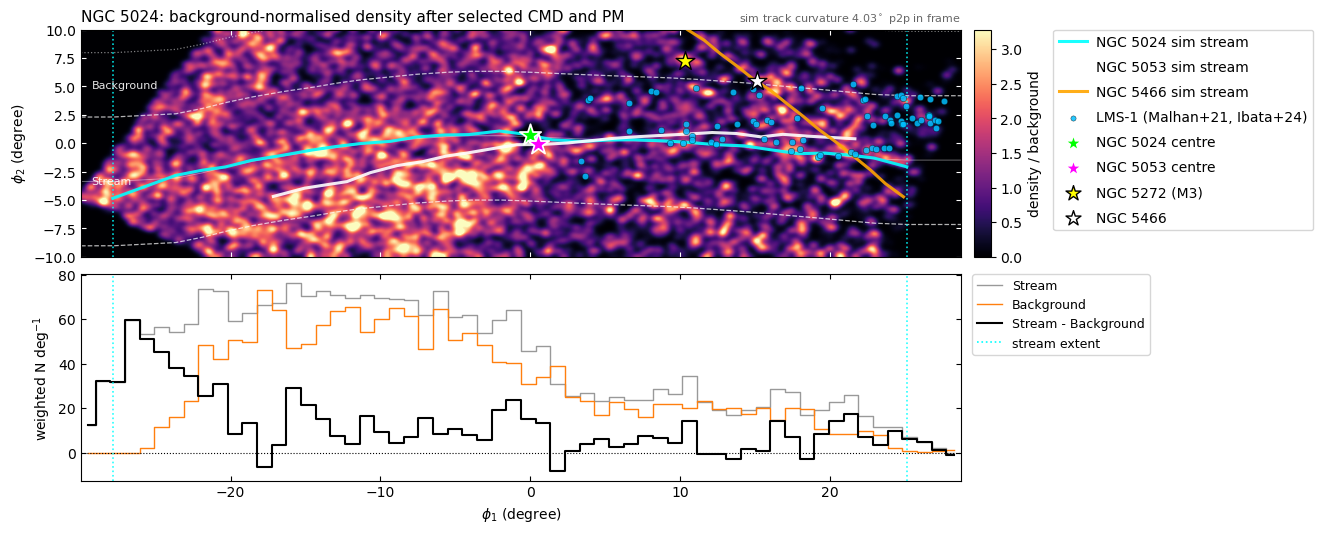

In [43]:
w_pm = pm_weight(combined_iso, stream_simulated_n5024,
                 pmra_ivar="pmra_ivar", pmdec_ivar="pmdec_ivar")
# NGC 5024's stream segment is thin, so use a narrow on-stream band
# (= the matched-filter corridor, 3 * tidal radius) for good contrast,
# with a tight cross-track display range.
stream_width = 10 * rt_deg
# show_particles=False: NGC 5024's particles are drawn as a labelled centreline
# in overlay_reference instead of the default unlabelled cyan dots.
_ = density_profile_figure(
    combined_iso, stream_simulated_n5024, GC1, gc_label=GC1_LABEL,
    frame=frame_n5024,
    weights=w_pm, gc_mask_deg=2 * rt_deg,
    on_width=stream_width, bg_offset=stream_width, bg_width=stream_width,
    phi2_lim=(-10, 10), pix=0.1, smooth_deg=0.25, cmap="magma",
    show_particles=False, overlay_layers=overlay_reference)

Same background-subtracted density profile, but in flat-sky RA/Dec coordinates
(`frame=None`) instead of the great-circle stream frame. The bands follow the
curved dec(RA) centreline of the simulated stream; the cross-track display range
auto-fits to that track (`phi2_lim=None`).

[density profile] masked 438 stars within 1.13 deg of NGC 5024
[density profile] frame phi2 track curvature: 20.743 deg peak-to-peak (smoothed; 23.651 raw) over 48.8 deg of phi1 -- the simulation is nearly a great circle in this frame
[density profile] weighted on-stream=2153  background=1638  (bg scale=1.00)


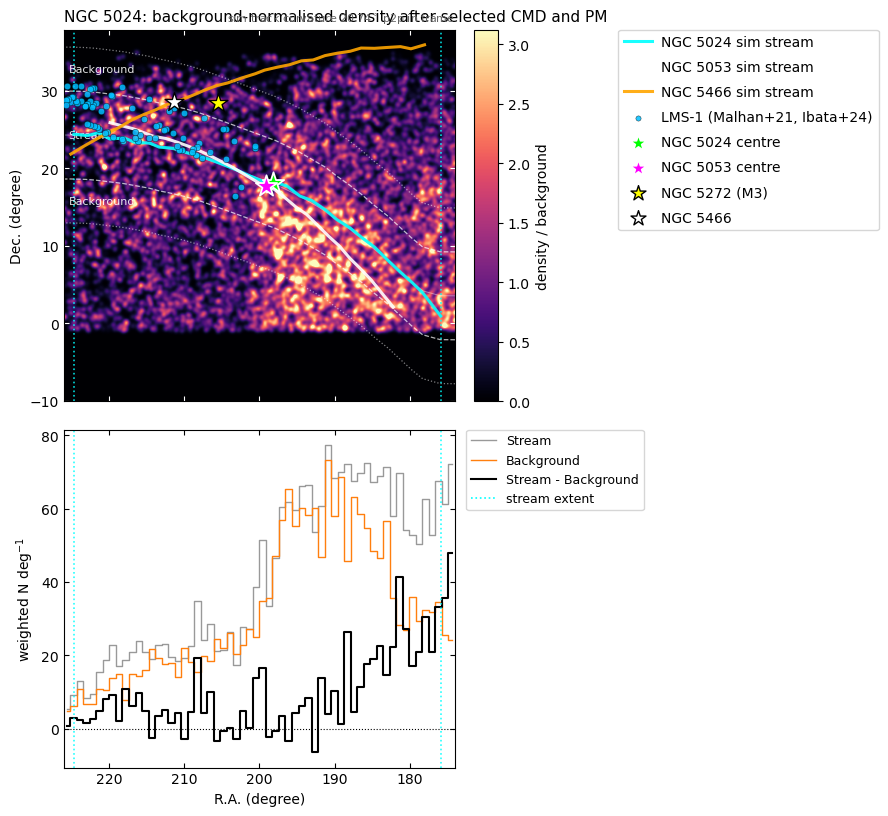

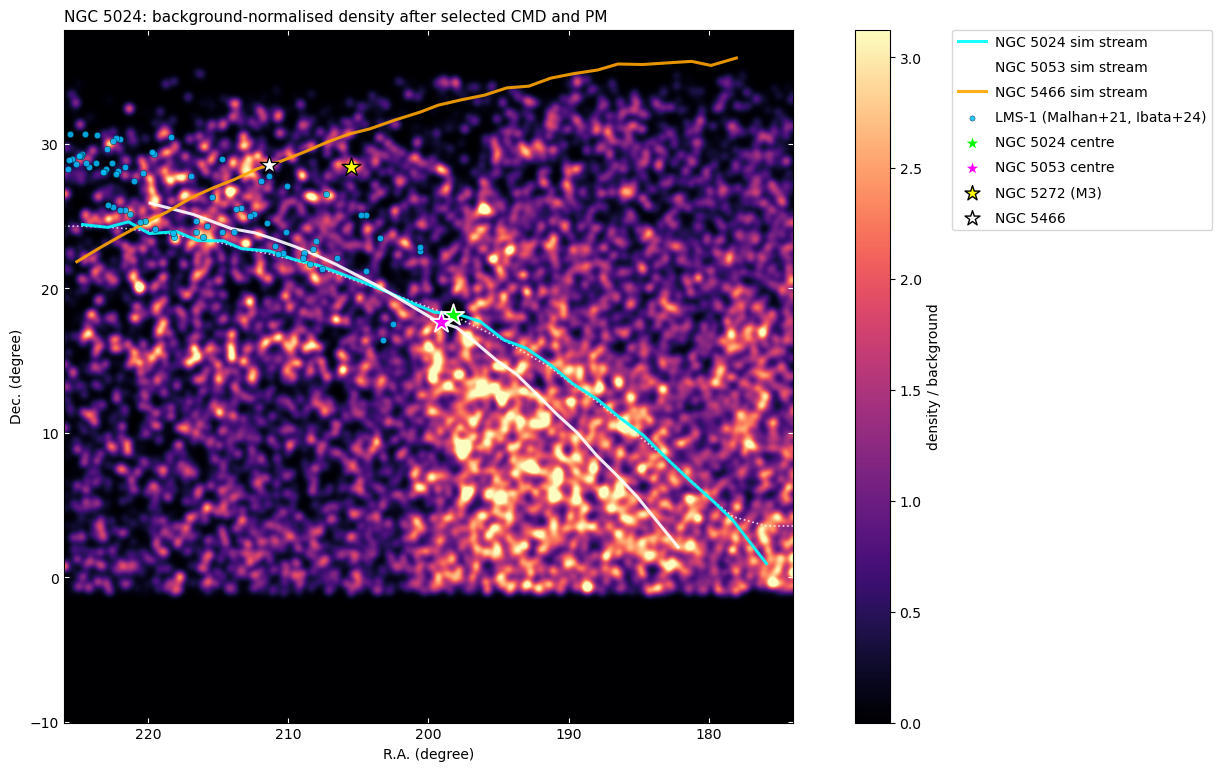

In [44]:
_ = density_profile_figure(
    combined_iso, stream_simulated_n5024, GC1, gc_label=GC1_LABEL, frame=None,
    weights=w_pm, gc_mask_deg=2 * rt_deg,
    on_width=stream_width, bg_offset=stream_width, bg_width=stream_width,
    phi2_lim=None, pix=0.1, smooth_deg=0.25, cmap="magma",
    figsize=(16, 9),
    show_particles=False, overlay_layers=overlay_reference, show_map=True)

### 8. DESI cross-match + RV / [Fe/H] weighting, both clusters

Everything up to here is one selection: the stellar locus, the isochrone and the
PM cut are built on NGC 5024, and because NGC 5053 shares its distance,
metallicity and proper motion, its members are already sitting inside
`combined_iso`. The line-of-sight velocity is what tells the two apart
(M53 ~ -63 km/s vs NGC 5053 ~ +43 km/s), so this is where the pipeline splits in
two and each cluster gets its own RV + [Fe/H] weighting:

* **NGC 5053** (this cell): its members are picked out of the shared sample by a
  wide spatial region around the cluster, agreement with its systemic velocity,
  and its own [Fe/H].
* **NGC 5024** (8b): the matched-filter corridor candidates are weighted against
  the *simulated stream's* `v_hel(RA)` track -- a stream, not a single systemic
  velocity -- then by a [Fe/H] mixture.

Both produce the same pair of tables per cluster, so step 11 can overlay them
together.

[NGC 5053] 2332 CMD+PM stars within 5.99 deg (20 rt) of NGC 5053
[crossmatch] 180 / 2332 matched; copied ['VRAD_CORRECTED', 'VRAD_ERR', 'FEH_CORRECTED', 'FEH_ERR']
[NGC 5053] 180 of 2332 have DESI spectra


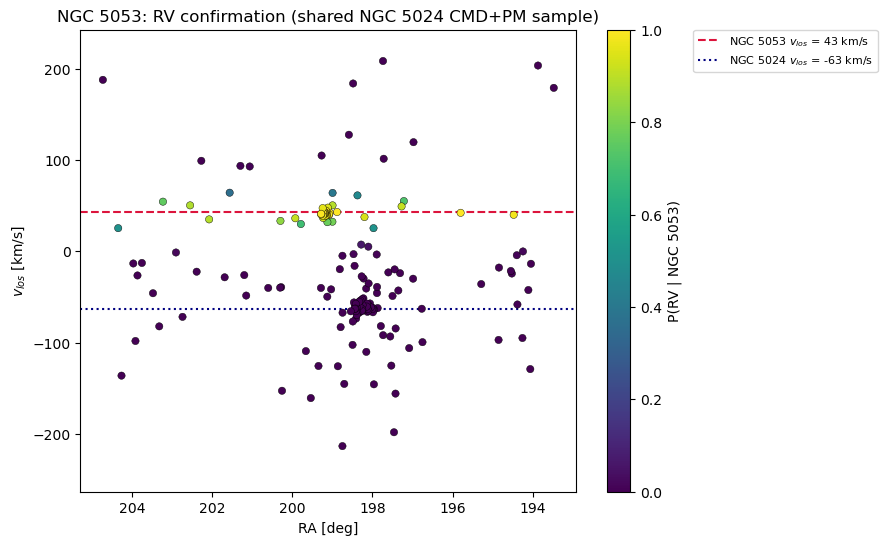

[NGC 5053] 41 stars with P_rv > 0.5 around v_los = 42.8 km/s
[NGC 5053] P_feh > 0.5 around [Fe/H] = -2.27: kept 30 / 41 (1 without a measured [Fe/H])
[NGC 5053] 180 DESI-matched in region
[NGC 5053] 6 confirmed members excl. core


In [45]:
# NGC 5053 membership: a wide spatial region around the cluster (x tidal radii),
# a velocity tolerance (km/s) added in quadrature to the per-star RV error when
# weighting against its systemic velocity, and the same P_feh threshold the
# NGC 5024 candidates are cut on in 8b, so both clusters are selected on RV AND
# [Fe/H]. Set GC2_PFEH_MIN = None to let RV alone decide.
GC2_REGION_RT = 20.0
GC2_RV_TOL = 15.0
GC2_PFEH_MIN = 0.5

desi_mws = Table.read(DESI_FILE)

# NGC 5053: its members are already inside the shared CMD + PM sample, so they
# are isolated by region + RV + [Fe/H]. members_gc2_no_core (cluster core
# removed) is the companion of the NGC 5024 final candidates of step 9, and the
# magenta layer of the map in step 11.
members_gc2, members_gc2_no_core = confirm_ngc5053(
                              combined_iso, desi_mws, GC1, GC1_LABEL,
                              GC2, GC2_LABEL, GC2_FEH, GC2_RT_PC,
                              region_rt=GC2_REGION_RT, rv_tol=GC2_RV_TOL,
                              pfeh_min=GC2_PFEH_MIN)

#### 8b. RV + [Fe/H] weighting of the NGC 5024 corridor candidates

The NGC 5024 half of the split: the matched-filter corridor candidates are
cross-matched against DESI, weighted by their agreement with the simulated
stream's `v_hel(RA)` track (`P_rv`) and then by a 2-component [Fe/H] mixture
(`P_feh`), keeping the stars that pass both.

[crossmatch] 206 / 2996 matched; copied ['VRAD_CORRECTED', 'VRAD_ERR', 'FEH_CORRECTED', 'FEH_ERR']
w_vlos > 0.5: 110 of 206


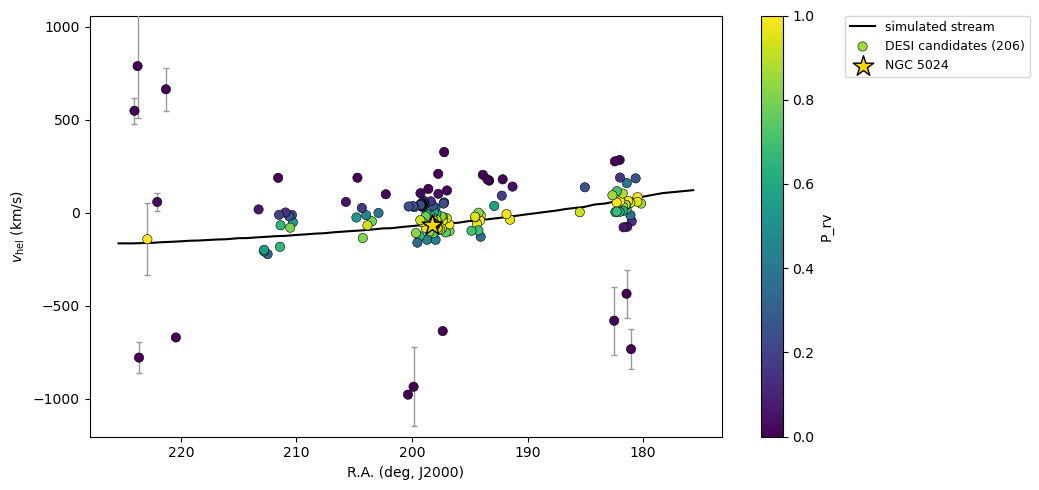

107 of 110 RV-passed stars have [Fe/H]
means: [-1.83 -1.44]  sigmas: [0.42 0.4 ]  stream: 0


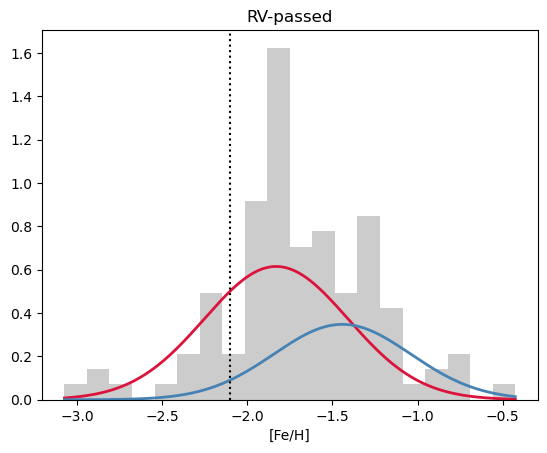

82 candidates with P_rv > 0.5 and P_feh > 0.5
[both clusters] 82 NGC 5024 + 30 NGC 5053 spectroscopic candidates


In [46]:
cand = crossmatch_desi(candidates, desi_mws)
cand_with_spec = cand[cand["has_desi"]]

d_good = rv_weight(cand_with_spec, stream_simulated_n5024, GC1)
# RV selection diagnostic: stream v_hel(RA) track + DESI candidates coloured
# by their RV membership likelihood P_rv (added in place by rv_weight).
rv_selection_plot(cand_with_spec, stream_simulated_n5024, GC1, gc_label=GC1_LABEL,
                  color_col="P_rv")
d_good = feh_weight(d_good, GC1_FEH)

d_good_spec = d_good[(d_good["P_rv"] > 0.5) & (d_good["P_feh"] > 0.5)]
print(f"{len(d_good_spec)} candidates with P_rv > 0.5 and P_feh > 0.5")
print(f"[both clusters] {len(d_good_spec)} {GC1_LABEL} + {len(members_gc2)} "
      f"{GC2_LABEL} spectroscopic candidates")

### 9. Drop stars inside the cluster tidal radius + final map

28 final candidates after excluding stars within 1.134 deg of NGC 5024
[matched filter] N_stars=31835  N_eff=9848  (N_eff/N=0.309)


[matched filter] stars inside band = 2996/31835  (sum w inside = 753 of 5745)


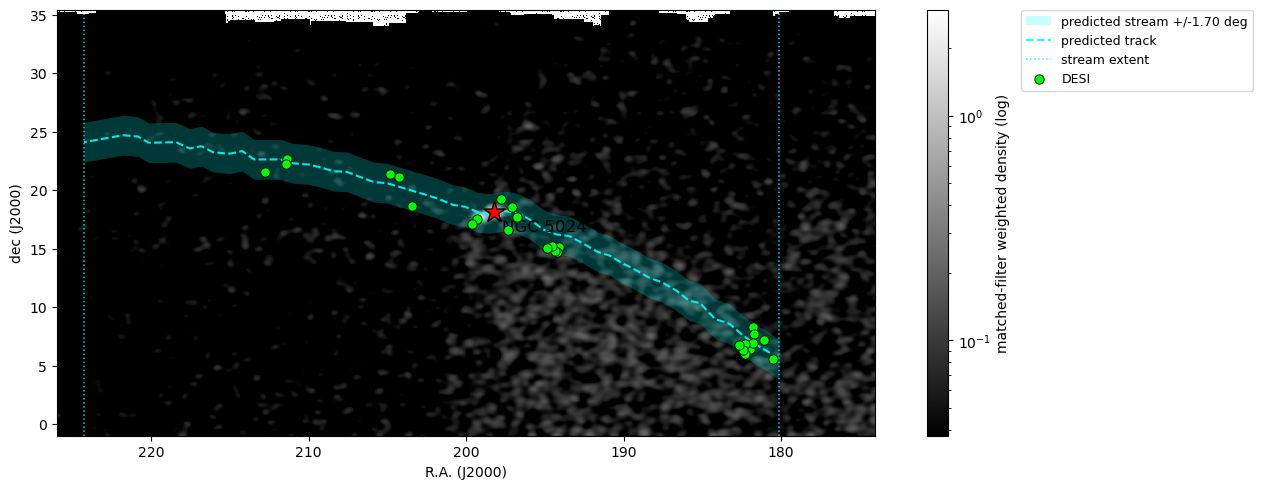

In [47]:
gc_coord = SkyCoord(ra=GC1["RA"] * u.deg, dec=GC1["DEC"] * u.deg)
cand_coords = SkyCoord(ra=d_good_spec["ra"] * u.deg,
                       dec=d_good_spec["dec"] * u.deg)
outside_tidal = gc_coord.separation(cand_coords) > 2 * rt_deg * u.deg
final_candidates = d_good_spec[outside_tidal]
print(f"{outside_tidal.sum()} final candidates after excluding stars "
      f"within {2 * rt_deg:.3f} deg of {GC1_LABEL}")

_ = matched_filter_map(
    combined_iso, stream_simulated_n5024, GC1, gc_label=GC1_LABEL,
    pmra_ivar="pmra_ivar", pmdec_ivar="pmdec_ivar",
    cmap="gray", vmin_pct=70, show_band=True, band_width_deg=band_width,
    return_mask=True, pix=0.1, smooth_deg=0.2,
    overlay_tab=final_candidates)

### 10. Candidate summary

Both clusters' final candidates, held in memory: NGC 5024's `d_good_spec`
(including the cluster) and `final_candidates` (cluster removed) from steps 8b-9,
and NGC 5053's `members_gc2` / `members_gc2_no_core` from step 8.

In [48]:
print(f"{GC1_LABEL}: {len(d_good_spec)} spectroscopic candidates (incl. cluster), "
      f"{len(final_candidates)} final stream candidates (excl. cluster)")
print(f"{GC2_LABEL}: {len(members_gc2)} confirmed members (incl. cluster), "
      f"{len(members_gc2_no_core)} excl. core")

NGC 5024: 82 spectroscopic candidates (incl. cluster), 28 final stream candidates (excl. cluster)
NGC 5053: 30 confirmed members (incl. cluster), 6 excl. core


### 11. Density map with the confirmed candidates and the neighbouring streams

The same background-subtracted RA/Dec map as step 7b (`combined_iso` weighted by
the PM matched filter), but with everything worth comparing against it drawn on
top instead of the default unlabelled particle dots:

* the simulated stream centrelines of **NGC 5024**, its companion **NGC 5053**
  and **NGC 5466**, binned into smooth tracks (`style="line"`),
* the published **LMS-1 STREAMFINDER members** (Malhan+21, Ibata+24) -- NGC 5024
  sits in LMS-1 debris, so this shows whether the overdensity follows the known
  stream rather than the cluster,
* the **spectroscopically confirmed candidates** of both clusters (`P_rv > 0.5`
  and `P_feh > 0.5`, cluster cores removed): NGC 5024's from step 9 in memory,
  NGC 5053's from `confirm_ngc5053` in step 8,
* the **cluster centres** of NGC 5024, NGC 5053, NGC 5272 (M3) and NGC 5466.

The band geometry is wider than step 7b (`OVERLAY_STREAM_WIDTH_RT` tidal radii):
this map is about the large-scale debris field, not the thin matched-filter
corridor. Needs steps 7b (`w_pm`), 8 and 9 to have run.

overlaying 28 NGC 5024 + 6 NGC 5053 confirmed candidates
[density profile] masked 438 stars within 1.13 deg of NGC 5024
[density profile] frame phi2 track curvature: 20.743 deg peak-to-peak (smoothed; 23.651 raw) over 48.8 deg of phi1 -- the simulation is nearly a great circle in this frame
[density profile] weighted on-stream=3791  background=1590  (bg scale=1.00)


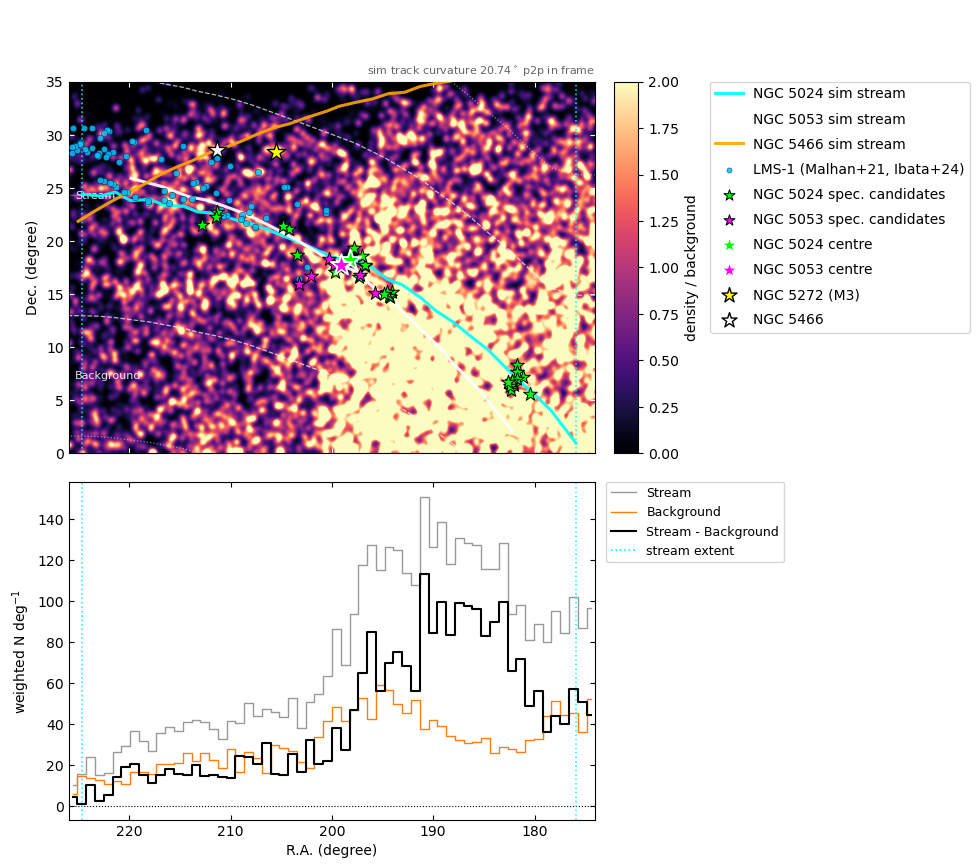

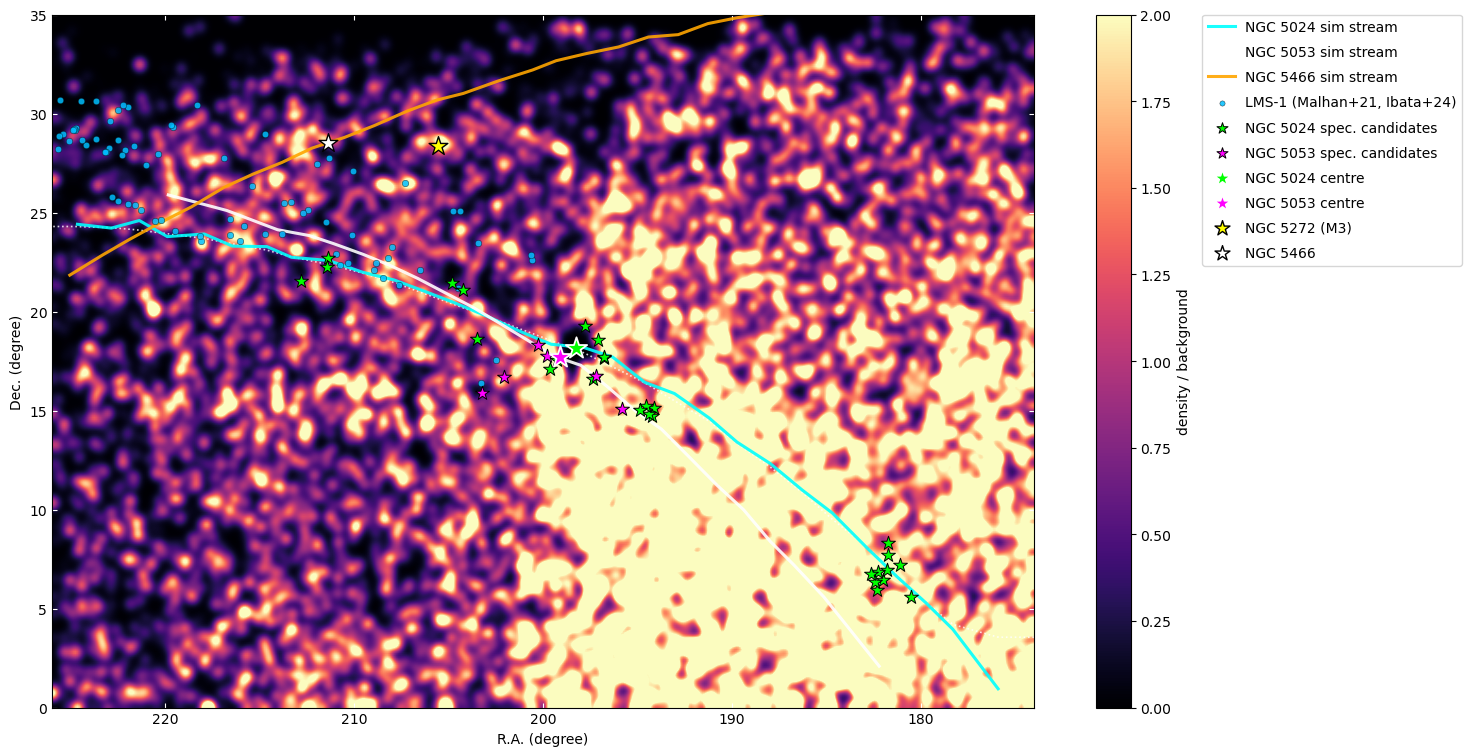

In [49]:
# Map geometry: a wider on-stream / background band than step 7b, since this map
# is about the large-scale debris field rather than the thin corridor.
OVERLAY_STREAM_WIDTH_RT = 20.0   # on-stream = background width, in tidal radii
OVERLAY_DEC_LIM = (0.0, 35.0)    # cross-track (Dec) display range of the map
OVERLAY_VMAX = 2.0               # density/background contrast ceiling

# confirmed candidates: NGC 5024's are `final_candidates` from step 9; NGC 5053's
# are `members_gc2_no_core` from step 8 (same core-excluded convention).
confirmed_gc2 = members_gc2_no_core
print(f"overlaying {len(final_candidates)} {GC1_LABEL} + {len(confirmed_gc2)} "
      f"{GC2_LABEL} confirmed candidates")

# the step 3b layers, with both clusters' candidates inserted before the centres.
overlay_layers = (overlay_streams
                  + candidate_layers(final_candidates, confirmed_gc2)
                  + overlay_centres)

# same RA/Dec density map as step 7b, plus the candidates.
overlay_width = OVERLAY_STREAM_WIDTH_RT * rt_deg
_ = density_profile_figure(
    combined_iso, stream_simulated_n5024, GC1, gc_label=GC1_LABEL, frame=None,
    weights=w_pm, gc_mask_deg=2 * rt_deg,
    on_width=overlay_width, bg_offset=overlay_width, bg_width=overlay_width,
    phi2_lim=OVERLAY_DEC_LIM, pix=0.1, smooth_deg=0.25, vmax=OVERLAY_VMAX,
    cmap="magma", figsize=(16, 9), show_particles=False,
    show_title=False, overlay_layers=overlay_layers, show_map=True)